Train/Test Split

In [2]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

#insira aqui o caminho para os dados limpos que você quer modelar:
DADOS_LIMPOS = Path("C:\\Users\\Master\\OneDrive\\Documentos\\Code\\Projeto-Trainee-I-Dados-2026.1\\dados\\dados_limpos.csv")

if not DADOS_LIMPOS.exists():
    raise FileNotFoundError("dados/dados_limpos.csv")

transpondo a coluna "Class" no indice 0 do dataframe:

In [3]:
df_limpo = pd.read_csv(DADOS_LIMPOS)
transpondo_class = df_limpo.pop("Class")
df_limpo.insert(0, "Class", transpondo_class)


C:\Users\Master\AppData\Local\Temp\ipykernel_2712\36720065.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_limpo.insert(0, "Class", transpondo_class)


Em X, temos os genes como variaveis preditoras. Em y, temos a variavel target (tipo de tumor)

Estabelecendo em 20% o volume de dados para teste e 80% para treino

In [4]:
genes = df_limpo.drop(columns=["Class"])
tumores = df_limpo["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    genes,
    tumores,
    test_size=0.2,
    random_state=42
)

Normalizando os dados

In [5]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.set_output(transform="pandas")

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Para realização do Label enconding verificamos inicialmente se existe alguma variável categórica no conjunto de treinamento X, e depois aplicamos o label enconding para o conjunto de dados Y, que representam o target: tipos de cancêr

In [6]:
colunas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Quantidade de colunas categóricas em X: {len(colunas_categoricas)}")

Quantidade de colunas categóricas em X: 0


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

for idx, classe in enumerate(le.classes_):
    print(f"{classe} -> {idx}")

BRCA -> 0
COAD -> 1
KIRC -> 2
LUAD -> 3
PRAD -> 4


In [8]:
import numpy as np
import shap 
from sklearn.ensemble import RandomForestClassifier

rf_inicial = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_inicial.fit(X_train_scaled, y_train)

importancias = pd.Series(rf_inicial.feature_importances_, index=X_train_scaled.columns)

features_grande = importancias[importancias > 0.001].index.to_list()

X_train_scaled = X_train_scaled[features_grande]
X_test_scaled = X_test_scaled[features_grande]

print(X_train_scaled.shape)

C:\Users\Master\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(640, 315)


Redução do dataset através de RFC utilizando valores de importância acima de 0.5%, para evitar o descarte de variáveis que possam ser relevantes para o modelo e retirar apenas os ruídos.

In [9]:
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_final.fit(X_train_scaled, y_train)

amostra_shap = X_train_scaled.sample(n=min(5000, len(X_train_scaled)), random_state=42)

explainer = shap.TreeExplainer(rf_final)
shap_valores = explainer(amostra_shap)
vals = shap_valores.values
if vals.ndim == 3:
    media_shap = np.abs(vals).mean(axis=(0,2))
importancia_shap = pd.Series(media_shap, index=X_train_scaled.columns)
features_finais = importancia_shap.sort_values(ascending=False).head(50).index.to_list()

X_train_scaled = X_train_scaled[features_finais]
X_test_scaled = X_test_scaled[features_finais]



Com o novo X_train utiliza-se RFC novamente para prever as variáveis úteis, depois foi utilizado o SHAP para obter as maiores importâncias das features restantes e assim reduzir o X_train_scaled para as 50 features mais relevantes

In [10]:
for i, gene in enumerate(features_finais,1):
    print(f"{i} : {gene}")

1 : gene_7964
2 : gene_18746
3 : gene_10731
4 : gene_15589
5 : gene_5407
6 : gene_15987
7 : gene_16246
8 : gene_17904
9 : gene_18178
10 : gene_6876
11 : gene_16358
12 : gene_15895
13 : gene_18753
14 : gene_203
15 : gene_15899
16 : gene_5578
17 : gene_9176
18 : gene_13818
19 : gene_6733
20 : gene_11903
21 : gene_219
22 : gene_17664
23 : gene_15898
24 : gene_2318
25 : gene_8014
26 : gene_5727
27 : gene_8801
28 : gene_4918
29 : gene_9652
30 : gene_17316
31 : gene_2778
32 : gene_14798
33 : gene_12983
34 : gene_15896
35 : gene_9177
36 : gene_6748
37 : gene_18135
38 : gene_1122
39 : gene_7238
40 : gene_12078
41 : gene_5598
42 : gene_15591
43 : gene_9184
44 : gene_17993
45 : gene_14503
46 : gene_8348
47 : gene_223
48 : gene_15473
49 : gene_3439
50 : gene_5597


Treinamento do algoritmo

In [11]:
modelo_final = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

# Treinando o modelo com as 50 features selecionadas
modelo_final.fit(X_train_scaled, y_train)

#Realizando as predições com os dados de teste iniciais
y_pred = modelo_final.predict(X_test_scaled)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        61
        COAD       1.00      1.00      1.00        17
        KIRC       1.00      1.00      1.00        25
        LUAD       1.00      1.00      1.00        29
        PRAD       1.00      1.00      1.00        29

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



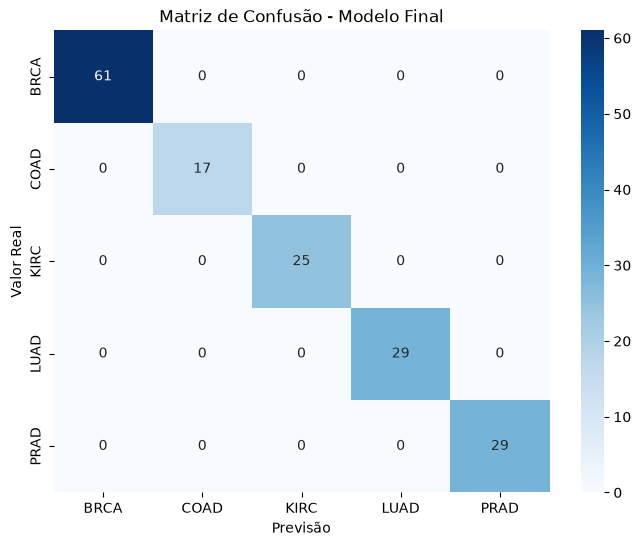

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Modelo Final')
plt.xlabel('Previsão')
plt.ylabel('Valor Real')
plt.show()

### Análise Breve dos Resultados

* **Desempenho Geral:** O modelo Random Forest atingiu **100% de Acurácia, Precision, Recall e F1-Score** no conjunto de teste ($N = 161$).
* **Significância das Features:** O processo de redução de dimensionalidade por Random Forest e SHAP identificou com precisão os 50 genes com maior poder de separação entre os tipos de tumores (BRCA, COAD, KIRC, LUAD e PRAD).
* **Considerações Práticas:** 
  * O resultado perfeito evidencia que as assinaturas genéticas selecionadas possuem altíssima separabilidade linear e não-linear para estas classes.
  * Como boa prática para trabalhos futuros ou validações em produção, recomenda-se testar o modelo em um dataset totalmente externo ou aplicar *Cross-Validation* para descartar hipóteses de over-fitting ou vazamento residual no pipeline.

In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo_final, genes, tumores, cv=5)
df_folds = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(scores))],
    'Acurácia': [f"{score * 100:.2f}%" for score in scores]
})

df_folds.loc[len(df_folds)] = ['Média Geral', f"{scores.mean() * 100:.2f}%"]
display(df_folds)

,Fold,Acurácia
0,Fold 1,98.76%
1,Fold 2,100.00%
2,Fold 3,100.00%
3,Fold 4,99.38%
4,Fold 5,100.00%
5,Média Geral,99.63%
